In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Base com quali

In [2]:
df_com_quali = pd.read_csv(r"D:\pedro\Documents\modelo_f1\DATA\oficial.csv")
# df_sem_quali.drop(columns=["posicao_quali_atual", "q1_atual", "q2_atual", "q3_atual", "dif_para_pole_atual"], inplace=True)
df_com_quali.head()

,temporada_atual,rodada_atual,id_piloto_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,id_circuito_atual,id_equipe_atual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2018,1,alonso,11.0,83597.0,83692.0,NaN,5,albert_park,mclaren,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
1,2018,1,bottas,10.0,83686.0,82089.0,NaN,8,albert_park,mercedes,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
2,2018,1,brendon_hartley,16.0,84532.0,NaN,NaN,15,albert_park,toro_rosso,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
3,2018,1,ericsson,17.0,84556.0,NaN,NaN,19,albert_park,sauber,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5
4,2018,1,gasly,20.0,85295.0,NaN,NaN,18,albert_park,toro_rosso,...,NaN,NaN,NaN,NaN,NaN,24.08,36.32,30.92,0,4.5


In [3]:
df_com_quali["target"] = (df_com_quali["target"] <= 3).astype(int)

In [4]:
df_com_quali["posicao_equipe_anterior"] = pd.to_numeric(df_com_quali["posicao_equipe_anterior"], errors="coerce")

df_com_quali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3612 entries, 0 to 3611
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temporada_atual               3612 non-null   int64  
 1   rodada_atual                  3612 non-null   int64  
 2   id_piloto_atual               3612 non-null   object 
 3   posicao_quali_atual           3605 non-null   float64
 4   q1_atual                      3541 non-null   float64
 5   q2_atual                      2643 non-null   float64
 6   q3_atual                      1746 non-null   float64
 7   target                        3612 non-null   int32  
 8   id_circuito_atual             3612 non-null   object 
 9   id_equipe_atual               3612 non-null   object 
 10  grid_anterior                 3403 non-null   float64
 11  posicao_ultima_corrida        3403 non-null   float64
 12  status                        3403 non-null   object 
 13  pon

In [5]:
df_com_quali.describe()

,temporada_atual,rodada_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
count,3612.000000,3612.000000,3605.000000,3541.000000,2643.000000,1746.000000,3612.000000,3403.000000,3403.000000,3403.000000,...,3417.000000,3417.000000,3417.000000,3417.000000,3417.000000,3612.000000,3612.000000,3612.000000,3612.000000,3612.000000
mean,2021.831395,11.097453,10.512067,85323.007060,84512.454408,84217.270332,0.149502,10.272113,10.514840,5.070967,...,10.518557,10.517504,0.546093,-0.238654,0.001054,23.440631,35.365133,53.623560,0.033223,5.357032
std,2.430326,6.445127,5.776947,12075.483459,11603.941979,11725.322821,0.356632,5.823335,5.790889,7.215496,...,4.659359,4.428662,1.024151,3.338725,1.472039,4.925805,9.122735,16.604338,0.179242,16.279797
min,2018.000000,1.000000,1.000000,63807.000000,63015.000000,62939.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,-18.000000,-6.800000,9.500000,15.210000,7.110000,0.000000,0.000000
25%,2020.000000,5.000000,6.000000,76458.000000,75848.500000,75331.500000,0.000000,5.000000,5.000000,0.000000,...,7.000000,7.000000,0.000000,-2.000000,-0.730000,20.120000,28.970000,42.320000,0.000000,0.000000
50%,2022.000000,11.000000,11.000000,84337.000000,83914.000000,83889.000000,0.000000,10.000000,11.000000,0.000000,...,11.000000,11.200000,0.000000,0.000000,0.000000,23.480000,35.375000,54.720000,0.000000,0.000000
75%,2024.000000,16.000000,15.000000,92449.000000,91628.500000,91303.750000,0.000000,15.000000,16.000000,9.000000,...,14.330000,14.000000,1.000000,2.000000,0.750000,27.130000,42.030000,63.900000,0.000000,0.000000
max,2026.000000,24.000000,22.000000,141611.000000,126688.000000,124933.000000,1.000000,22.000000,22.000000,26.000000,...,22.000000,22.000000,7.000000,14.000000,5.530000,36.570000,54.530000,96.440000,1.000000,98.000000


In [6]:
df_com_quali.drop(columns=["id_piloto_atual"], inplace=True)

In [7]:
X = df_com_quali.drop(columns=['target'])
y = df_com_quali['target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [10]:
onehotencoder = ColumnTransformer(transformers=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore'), ['id_circuito_atual', 'id_equipe_atual', 'status'])
], remainder='passthrough')

In [11]:
X_train_transformed = onehotencoder.fit_transform(X_train)
X_test_transformed = onehotencoder.transform(X_test)

In [12]:
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [300, 500, 700, 1000],
    "scale_pos_weight": [2, 3],       
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8], 
    "min_child_weight": [5, 7, 10],     
    "gamma": [0.2, 0.4, 0.6],          
    "reg_alpha": [0, 0.1, 0.5],       
    "reg_lambda": [1, 1.5, 2],       
}

xgb_model = xgb.XGBClassifier(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="f1", n_iter=150, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_transformed, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia:", grid_search.best_score_)

Fitting 10 folds for each of 150 candidates, totalling 1500 fits
Melhores parâmetros: {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}
Melhor acurácia: 0.6932054875488701


In [13]:
y_pred = best_xgb.predict(X_test_transformed)

test_accuracy = accuracy_score(y_test, y_pred)
print("Acurácia: ", test_accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia:  0.8962655601659751

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       616
           1       0.62      0.78      0.69       107

    accuracy                           0.90       723
   macro avg       0.79      0.85      0.81       723
weighted avg       0.91      0.90      0.90       723


Matriz de confusão:
 [[565  51]
 [ 24  83]]


Entendendo as features utilizadas

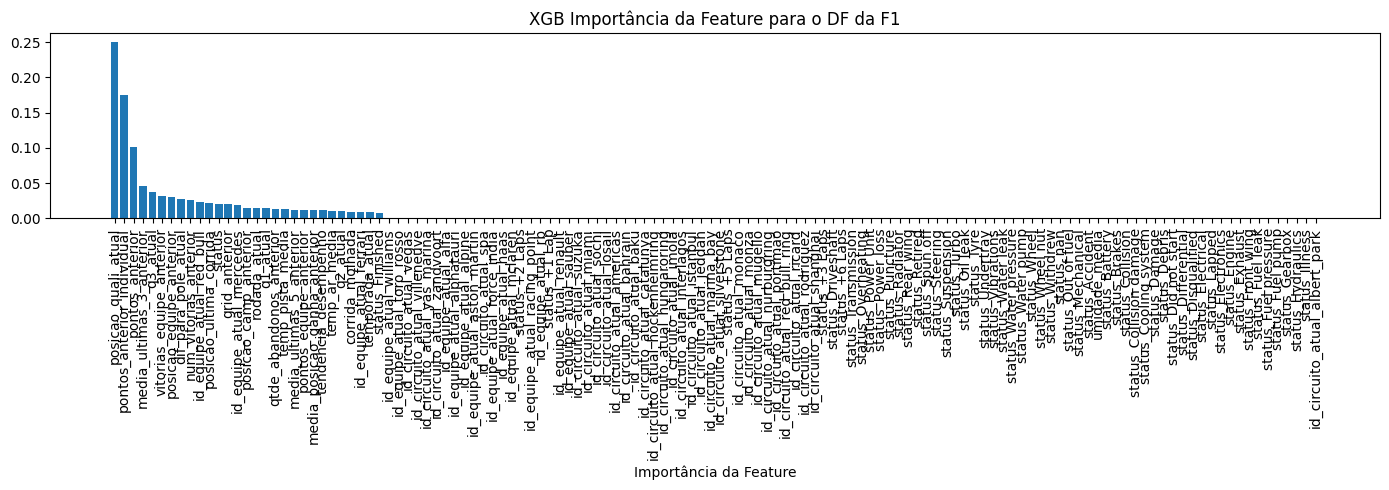

In [14]:
colunas_ohe = onehotencoder.named_transformers_['OneHot'].get_feature_names_out(['id_circuito_atual', 'id_equipe_atual', 'status'])
colunas_resto = [c for c in X.columns if c not in ['id_circuito_atual', 'id_equipe_atual']]
feature_names = list(colunas_ohe) + list(colunas_resto)

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF da F1")
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(best_xgb, r"D:\pedro\Documents\modelo_f1\modelos\modelo_com_quali.pkl")
joblib.dump(onehotencoder, r"D:\pedro\Documents\modelo_f1\modelos\encoder_com_quali.pkl")

# Testes

In [2]:
df = pd.read_csv(r"D:\pedro\Documents\modelo_f1\DATA\analise.csv")

In [3]:
df.head()

,temporada_atual,rodada_atual,id_piloto_atual,id_circuito_atual,id_equipe_atual,grid_anterior,posicao_ultima_corrida,pontos_anterior_individual,media_posicao_ganha_anterior,status,...,num_vitorias_anterior,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2026,8,hamilton,red_bull_ring,ferrari,2,1,25,1.67,Finished,...,1,1.67,3.4,0,-1.73,29.47,35.4,29.33,0,0.0
1,2026,8,russell,red_bull_ring,mercedes,1,2,18,-8.33,Finished,...,1,11.00,8.2,1,2.80,29.47,35.4,29.33,0,0.0
2,2026,8,norris,red_bull_ring,mclaren,4,3,15,-8.33,Finished,...,0,13.33,9.4,3,3.93,29.47,35.4,29.33,0,0.0
3,2026,8,max_verstappen,red_bull_ring,red_bull,5,4,12,-5.33,Finished,...,0,9.67,8.4,2,1.27,29.47,35.4,29.33,0,0.0
4,2026,8,piastri,red_bull_ring,mclaren,7,5,10,-1.00,Finished,...,0,7.00,5.2,2,1.80,29.47,35.4,29.33,0,0.0


In [4]:
import joblib
import pandas as pd

modelo = joblib.load(r"D:\pedro\Documents\modelo_f1\modelos\modelo_com_quali.pkl")
encoder = joblib.load(r"D:\pedro\Documents\modelo_f1\modelos\encoder_com_quali.pkl")

df = pd.read_csv(r"D:\pedro\Documents\modelo_f1\DATA\analise.csv")

X_train_transformed = encoder.transform(df)
predicoes = modelo.predict_proba(X_train_transformed)

print(predicoes)


ValueError: columns are missing: {'q3_atual', 'q2_atual', 'dif_para_pole_atual', 'q1_atual', 'posicao_quali_atual'}

In [ ]:
print(encoder.feature_names_in_)

In [ ]:
probs = modelo.predict_proba(X_train_transformed)[:, 1]

df_result = df.copy()
df_result['prob_podio'] = probs
df_result['predicao'] = modelo.predict(X_train_transformed)

predict = df_result[['id_piloto_atual', 'prob_podio', 'predicao']].sort_values('prob_podio', ascending=False)
print(predict)

In [ ]:
json_string = predict.to_json(orient='records', indent=4)
print(json_string)

In [ ]:
import os
import streamlit as st
from google.cloud import storage
from google.oauth2 import service_account
import pickle


def salva_gcs(caminho_gcs, caminho_local):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "D:\pedro\Documents\modelo_f1\clever-axe-457319-g8-833d2d4ab67f.json"

    client = client = storage.Client()
    bucket = client.bucket("f1-dashboard-pilotos")
    blob = bucket.blob(caminho_gcs)

    blob.upload_from_filename(caminho_local)


modelos = [
    ("modelos/modelo_com_quali.pkl",  r"D:\pedro\Documents\modelo_f1\modelos\modelo_com_quali.pkl"),
    ("modelos/encoder_com_quali.pkl", r"D:\pedro\Documents\modelo_f1\modelos\encoder_com_quali.pkl"),
]
for caminho_gcs, caminho_local in modelos:
    salva_gcs(caminho_gcs, caminho_local)

In [ ]:
from sklearn.metrics import classification_report
import json
import os

metricas = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

metricas_classe_1 = metricas["1"]
metricas_classe_1["accuracy"] = test_accuracy

def salva_gcs(dados):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "D:\pedro\Documents\modelo_f1\clever-axe-457319-g8-833d2d4ab67f.json"

    client = client = storage.Client()
    bucket = client.bucket("f1-dashboard-pilotos")
    blob = bucket.blob("metricas_com_quali.json")
    blob.upload_from_string(
        json.dumps(dados), 
        content_type="application/json"
    )

salva_gcs(metricas_classe_1)

<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pedro\AppData\Local\Temp\ipykernel_10908\1192199847.py:20: SyntaxWarning: invalid escape sequence '\p'
  os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "D:\pedro\Documents\modelo_f1\clever-axe-457319-g8-833d2d4ab67f.json"
